## Support Vector Machines (SVM)

**Support Vector Machines (SVMs)** are powerful and versatile machine learning models capable of performing **linear or non-linear classification, regression, and even outlier detection**. SVMs are particularly well-suited for classification of complex small-to-medium sized datasets.

The core idea behind SVMs is to find the **optimal hyperplane** that best separates different classes in the feature space (for classification) or finds the best fit line/plane while allowing for a margin of error (for regression).


### Key Concepts

  * **Hyperplane**: In an $n$-dimensional feature space, a hyperplane is a flat affine subspace of dimension $n-1$. For 2D data, it's a line; for 3D data, it's a plane.
  * **Support Vectors**: These are the data points closest to the decision boundary (hyperplane). They are the critical elements that define the hyperplane's position and orientation. Removing them would change the position of the hyperplane.
  * **Margin**: The distance between the hyperplane and the nearest data point from either class (the support vectors). SVMs aim to maximize this margin, as a larger margin generally leads to better generalization performance.
  * **Hard Margin vs. Soft Margin**:
      * **Hard Margin SVM**: Aims to find a hyperplane that perfectly separates the classes with no training errors allowed. This is sensitive to outliers and might not be possible for non-linearly separable data.
      * **Soft Margin SVM**: Allows for some misclassifications (violations of the margin) by introducing a **slack variable ($\\xi$)** and a **regularization parameter (C)**. A smaller C allows more violations (wider margin, higher bias, lower variance), while a larger C penalizes violations more heavily (narrower margin, lower bias, higher variance).
  * **Kernel Trick**: One of the most powerful features of SVMs. It allows SVMs to perform non-linear classification by implicitly mapping the input features into a higher-dimensional feature space where the data might become linearly separable. Common kernels include:
      * **Linear Kernel**: $K(\\mathbf{x}, \\mathbf{x'}) = \\mathbf{x}^T \\mathbf{x'}$ (for linearly separable data)
      * **Polynomial Kernel**: $K(\\mathbf{x}, \\mathbf{x'}) = (\\gamma \\mathbf{x}^T \\mathbf{x'} + r)^d$ (where $d$ is the degree)
      * **Radial Basis Function (RBF) / Gaussian Kernel**: $K(\\mathbf{x}, \\mathbf{x'}) = \\exp(-\\gamma ||\\mathbf{x} - \\mathbf{x'}||^2)$ (very popular for non-linear data)
      * **Sigmoid Kernel**: $K(\\mathbf{x}, \\mathbf{x'}) = \\tanh(\\gamma \\mathbf{x}^T \\mathbf{x'} + r)$

### SVM for Classification (SVC)



#### Example Data and Code (SVC)

Let's classify two types of flowers based on their sepal length and sepal width using the Iris dataset (a classic example).

**Example Data (Iris subset):**

We'll use a subset of the Iris dataset, focusing on 'setosa' and 'versicolor' classes.

| Sepal Length (cm) | Sepal Width (cm) | Species      |
| :---------------- | :--------------- | :----------- |
| 5.1               | 3.5              | setosa       |
| 4.9               | 3.0              | setosa       |
| ...               | ...              | ...          |
| 7.0               | 3.2              | versicolor   |
| 6.4               | 3.2              | versicolor   |
| ...               | ...              | ...          |


--- SVM for Classification ---
Training data shape: (70, 2), Test data shape: (30, 2)

--- Linear SVC ---
Accuracy (Linear SVC): 1.0000
Classification Report (Linear SVC):
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


--- RBF Kernel SVC ---
Accuracy (RBF SVC): 1.0000
Classification Report (RBF SVC):
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



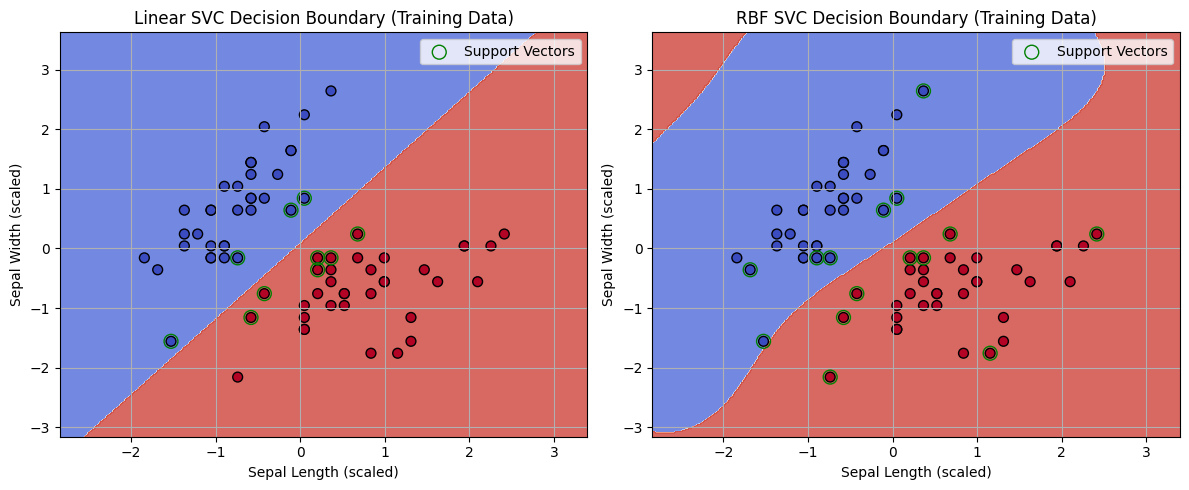

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # We take only the first two features (sepal length, sepal width)
y = (iris.target != 0) * 1  # Binary classification: 0 for setosa, 1 for non-setosa (versicolor/virginica)
                          # For simplicity, let's just pick two classes directly: setosa and versicolor
                          # Mask to get only setosa and versicolor
mask = (iris.target == 0) | (iris.target == 1)
X = iris.data[mask, :2]
y = iris.target[mask] # y will be 0 for setosa, 1 for versicolor

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- SVM for Classification ---")
print(f"Training data shape: {X_train_scaled.shape}, Test data shape: {X_test_scaled.shape}")

# 1. Train a Linear SVC model
print("\n--- Linear SVC ---")
linear_svc = SVC(kernel='linear', C=1.0, random_state=42)
linear_svc.fit(X_train_scaled, y_train)

# Make predictions
y_pred_linear = linear_svc.predict(X_test_scaled)

# Evaluate the model
print(f"Accuracy (Linear SVC): {accuracy_score(y_test, y_pred_linear):.4f}")
print("Classification Report (Linear SVC):\n", classification_report(y_test, y_pred_linear, target_names=iris.target_names[[0, 1]])) # Corrected target_names

# Function to plot decision boundaries
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k')
    plt.title(title)
    plt.xlabel('Sepal Length (scaled)')
    plt.ylabel('Sepal Width (scaled)')
    plt.grid(True)

plt.figure(figsize=(12, 5))

# Plot for Linear SVC
plt.subplot(1, 2, 1)
plot_decision_boundary(linear_svc, X_train_scaled, y_train, 'Linear SVC Decision Boundary (Training Data)')
# Highlight support vectors
plt.scatter(linear_svc.support_vectors_[:, 0], linear_svc.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='green', label='Support Vectors')
plt.legend()


# 2. Train an RBF Kernel SVC model (for non-linear separation)
print("\n--- RBF Kernel SVC ---")
rbf_svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42) # gamma='scale' uses 1 / (n_features * X.var())
rbf_svc.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rbf = rbf_svc.predict(X_test_scaled)

# Evaluate the model
print(f"Accuracy (RBF SVC): {accuracy_score(y_test, y_pred_rbf):.4f}")
print("Classification Report (RBF SVC):\n", classification_report(y_test, y_pred_rbf, target_names=iris.target_names[[0, 1]])) # Corrected target_names

# Plot for RBF Kernel SVC
plt.subplot(1, 2, 2)
plot_decision_boundary(rbf_svc, X_train_scaled, y_train, 'RBF SVC Decision Boundary (Training Data)')
# Highlight support vectors
plt.scatter(rbf_svc.support_vectors_[:, 0], rbf_svc.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='green', label='Support Vectors')
plt.legend()

plt.tight_layout()
plt.show()

### SVM for Regression (SVR)

**Support Vector Regression (SVR)** extends the concepts of SVM to regression problems. Instead of trying to fit a line to minimize the error, SVR tries to fit a line (or hyperplane) while allowing for a certain tolerance ($\\epsilon$) of error. It finds the function that deviates from the training data by a margin of at most $\\epsilon$, and at the same time is as flat as possible.

#### Example Data and Code (SVR)

Let's generate some synthetic noisy data and use SVR to fit a regression line/curve.

**Example Data (Synthetic):**

A simple linear relationship with some noise: $y = 2x + 1 + \text{noise}$


--- SVM for Regression ---
Training data shape (X): (70, 1), Training data shape (y): (70, 1)

--- Linear SVR ---
Mean Squared Error (Linear SVR): 1.6394
R-squared (Linear SVR): 0.6224

--- RBF Kernel SVR ---
Mean Squared Error (RBF SVR): 1.3312
R-squared (RBF SVR): 0.6934


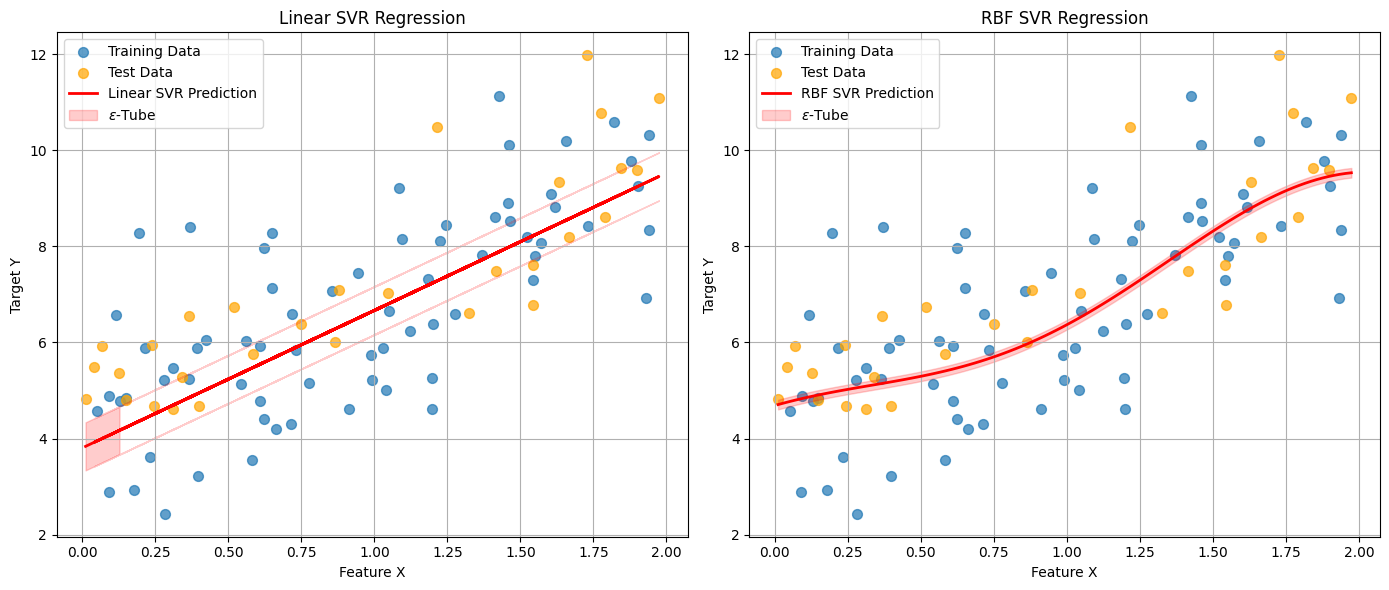

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Generate synthetic data for regression
np.random.seed(42)
X_reg = 2 * np.random.rand(100, 1) # Feature
y_reg = 4 + 3 * X_reg + np.random.randn(100, 1) * 1.5 # Target with noise

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Standardize the features (important for SVR)
scaler_reg_X = StandardScaler()
X_train_reg_scaled = scaler_reg_X.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg_X.transform(X_test_reg)

scaler_reg_y = StandardScaler() # It's good practice to scale target for SVR, then inverse transform predictions
y_train_reg_scaled = scaler_reg_y.fit_transform(y_train_reg)
y_test_reg_scaled = scaler_reg_y.transform(y_test_reg)


print("\n--- SVM for Regression ---")
print(f"Training data shape (X): {X_train_reg_scaled.shape}, Training data shape (y): {y_train_reg_scaled.shape}")

# 1. Train a Linear SVR model
print("\n--- Linear SVR ---")
linear_svr = SVR(kernel='linear', C=1.0, epsilon=0.5) # C=1.0, epsilon=0.5
linear_svr.fit(X_train_reg_scaled, y_train_reg_scaled.ravel()) # .ravel() converts y to 1D array

# Make predictions
y_pred_linear_scaled = linear_svr.predict(X_test_reg_scaled)
y_pred_linear = scaler_reg_y.inverse_transform(y_pred_linear_scaled.reshape(-1, 1)) # Inverse transform to original scale

# Evaluate the model
print(f"Mean Squared Error (Linear SVR): {mean_squared_error(y_test_reg, y_pred_linear):.4f}")
print(f"R-squared (Linear SVR): {r2_score(y_test_reg, y_pred_linear):.4f}")

# Plotting for Linear SVR
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_train_reg, y_train_reg, s=50, alpha=0.7, label='Training Data')
plt.scatter(X_test_reg, y_test_reg, s=50, alpha=0.7, label='Test Data', color='orange')
plt.plot(X_test_reg, y_pred_linear, color='red', linewidth=2, label='Linear SVR Prediction')
plt.fill_between(X_test_reg.flatten(), (y_pred_linear - linear_svr.epsilon).flatten(), (y_pred_linear + linear_svr.epsilon).flatten(),
                 color='red', alpha=0.2, label='$\epsilon$-Tube')
plt.title('Linear SVR Regression')
plt.xlabel('Feature X')
plt.ylabel('Target Y')
plt.legend()
plt.grid(True)

# 2. Train an RBF Kernel SVR model (for non-linear relationships)
print("\n--- RBF Kernel SVR ---")
rbf_svr = SVR(kernel='rbf', C=100.0, gamma=0.1, epsilon=0.1) # C and gamma are important hyperparameters
rbf_svr.fit(X_train_reg_scaled, y_train_reg_scaled.ravel())

# Make predictions
y_pred_rbf_scaled = rbf_svr.predict(X_test_reg_scaled)
y_pred_rbf = scaler_reg_y.inverse_transform(y_pred_rbf_scaled.reshape(-1, 1))

# Evaluate the model
print(f"Mean Squared Error (RBF SVR): {mean_squared_error(y_test_reg, y_pred_rbf):.4f}")
print(f"R-squared (RBF SVR): {r2_score(y_test_reg, y_pred_rbf):.4f}")

# Plotting for RBF SVR
plt.subplot(1, 2, 2)
plt.scatter(X_train_reg, y_train_reg, s=50, alpha=0.7, label='Training Data')
plt.scatter(X_test_reg, y_test_reg, s=50, alpha=0.7, label='Test Data', color='orange')
# To plot the curve, we need predictions across a range of X values
X_plot = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
X_plot_scaled = scaler_reg_X.transform(X_plot)
y_plot_rbf_scaled = rbf_svr.predict(X_plot_scaled)
y_plot_rbf = scaler_reg_y.inverse_transform(y_plot_rbf_scaled.reshape(-1, 1))
plt.plot(X_plot, y_plot_rbf, color='red', linewidth=2, label='RBF SVR Prediction')
plt.fill_between(X_plot.flatten(), (y_plot_rbf - rbf_svr.epsilon).flatten(), (y_plot_rbf + rbf_svr.epsilon).flatten(),
                 color='red', alpha=0.2, label='$\epsilon$-Tube')

plt.title('RBF SVR Regression')
plt.xlabel('Feature X')
plt.ylabel('Target Y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Explanation of SVR Example

In the SVR example:

  * We generate synthetic data that has a roughly linear relationship with some noise.
  * **Standardization is crucial** for SVR (and SVC) because the kernel functions (especially RBF) are sensitive to feature scales. The target variable `y` is also scaled for SVR, then inverse-transformed for evaluation.
  * **Linear SVR**: Fits a straight line. The plot shows the predicted line and the $\\epsilon$-tube around it. Most of the training points (and test points) fall within this tube. Only points outside the tube contribute to the penalty term $C \sum (\xi\_i + \xi\_i^*)$.
  * **RBF Kernel SVR**: This is more powerful and can fit non-linear patterns. While our synthetic data is linear, if there were a curved relationship, the RBF kernel would be able to model it. The plot for RBF SVR shows how it still tries to fit a line in this case, but with the potential for non-linearity if `gamma` was higher or the data was truly non-linear.

### Hyperparameters in SVM (C, gamma, epsilon)

  * **`C` (Regularization Parameter)**:

      * **Classification (SVC)**: Controls the penalty for misclassified points.
          * **Small C**: Allows more misclassifications (larger margin, more regularization, less prone to overfitting, higher bias, lower variance).
          * **Large C**: Penalizes misclassifications heavily (smaller margin, less regularization, prone to overfitting, lower bias, higher variance).
      * **Regression (SVR)**: Controls the penalty for points outside the ϵ-tube. Similar impact as in SVC.

  * **`kernel`**: Specifies the kernel type to be used in the algorithm. Common options are 'linear', 'poly', 'rbf', 'sigmoid'.

      * **'linear'**: Good for linearly separable data, very fast.
      * **'rbf' (Radial Basis Function)**: A general-purpose kernel that works well for non-linear decision boundaries. Most commonly used.
      * **'poly' (Polynomial)**: Captures polynomial relationships.

  * **`gamma` (Kernel Coefficient for 'rbf', 'poly', 'sigmoid')**:

      * **Small `gamma`**: A large influence radius for each training example, leading to a smoother decision boundary (lower variance, higher bias).
      * **Large `gamma`**: A small influence radius, leading to a more complex, wiggly decision boundary (higher variance, lower bias, prone to overfitting).

  * **`epsilon` (for SVR only)**:

      * Defines the **margin of tolerance** where no penalty is associated with errors.
      * A larger ϵ means a wider tube, allowing more errors to be tolerated and potentially leading to a simpler model (more regularization).
      * A smaller ϵ means a narrower tube, penalizing more errors and leading to a more complex model (less regularization).

Tuning these hyperparameters is crucial for achieving optimal performance with SVMs. This is typically done using techniques like Grid Search or Random Search with cross-validation.

SVMs are robust models, especially effective in high-dimensional spaces and when the number of features is greater than the number of samples. Their performance largely depends on selecting the right kernel and tuning the hyperparameters.

### Formula and Concepts (Linear SVC)

For a linearly separable binary classification problem, we want to find a hyperplane defined by $\mathbf{w} \cdot \mathbf{x} - b = 0$, where $\mathbf{w}$ is the weight vector (normal to the hyperplane) and $b$ is the bias (intercept).

#### **Decision Rule (Linear SVC)**

For a linearly separable binary classification problem, once the optimal hyperplane defined by $\mathbf{w} \cdot \mathbf{x} - b = 0$ is found, the decision rule to classify a new instance $\mathbf{x}$ is:

$$ \text{predict} = \begin{cases} 1 & \text{if } \mathbf{w} \cdot \mathbf{x} - b \ge 0 \\ -1 & \text{if } \mathbf{w} \cdot \mathbf{x} - b < 0 \end{cases} $$

This can also be written using the sign function:

$$ \text{predict} = \text{sgn}(\mathbf{w} \cdot \mathbf{x} - b) $$

For multi-class classification, strategies like one-vs-one or one-vs-rest are used, which involve training multiple binary SVCs.

To maximize the margin, we want to maximize $\frac{2}{||\mathbf{w}||}$. This is equivalent to minimizing $||\mathbf{w}||^2$.
With the introduction of slack variables for soft margin, the optimization problem for **SVC** is:

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2}||\mathbf{w}||^2 + C \sum_{i=1}^{m} \xi_i$$

Subject to the constraints:
$$y_i (\mathbf{w} \cdot \mathbf{x}_i - b) \ge 1 - \xi_i \quad \text{for all } i=1, \dots, m$$
$$\xi_i \ge 0 \quad \text{for all } i=1, \dots, m$$

Where:

  * $\mathbf{x}_i$ are the training instances.
  * $y_i$ are the class labels (usually -1 or 1 for binary classification).
  * $\mathbf{w}$ is the weight vector.
  * $b$ is the bias term.
  * $\xi_i$ ($x_i$) are the **slack variables**, representing the degree of misclassification of the $i$-th training instance.
  * $C$ is the **regularization parameter** (hyperparameter). It controls the trade-off between maximizing the margin and minimizing the classification error. A smaller $C$ leads to a wider margin but more training errors, while a larger $C$ leads to a narrower margin but fewer training errors.

#### Maximizing the Margin

In Support Vector Machines (SVMs), the core idea for classification is to find the **optimal hyperplane** that separates the different classes with the largest possible "margin".

The **margin** is defined as the distance between the hyperplane and the closest data points from either class. These closest points are called the **support vectors**.

Maximizing this margin is a key principle of SVMs because:

1.  **Improved Generalization**: A larger margin generally indicates a better separation between classes, which leads to better performance on unseen data (i.e., better generalization). It makes the classifier more robust to new data points that might be slightly different from the training examples.
2.  **Reduced Risk of Overfitting**: By finding the widest possible street between the classes, the SVM is less likely to be overly influenced by individual training points, thus reducing the risk of overfitting to the training data.

Mathematically, for a linear hyperplane defined by $\mathbf{w} \cdot \mathbf{x} - b = 0$, the distance from a point $\mathbf{x}_0$ to the hyperplane is $\frac{|\mathbf{w} \cdot \mathbf{x}_0 - b|}{||\mathbf{w}||}$. The support vectors are the points for which $|\mathbf{w} \cdot \mathbf{x}_i - b| = 1$. Therefore, the distance from the support vectors to the hyperplane is $\frac{1}{||\mathbf{w}||}$. The total margin is $\frac{2}{||\mathbf{w}||}$.

Maximizing the margin $\frac{2}{||\mathbf{w}||}$ is equivalent to minimizing $||\mathbf{w}||^2$. This minimization is the primary objective function in the SVM optimization problem, subject to the constraints that all training points are on the correct side of the margin (or within the allowed slack for soft margin SVMs).

### Formula and Concepts (Linear SVR)

For SVR, the goal is to find $\mathbf{w}$ and $b$ such that the function $f(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$ is as flat as possible (minimize $||\mathbf{w}||^2$), and the errors for all training points are within a specified margin $\\epsilon$.

The optimization problem for **SVR** is:

$$\min_{\mathbf{w}, b, \xi, \xi^*} \frac{1}{2}||\mathbf{w}||^2 + C \sum_{i=1}^{m} (\xi_i + \xi_i^*)$$

Subject to the constraints:
$$y_i - (\mathbf{w} \cdot \mathbf{x}_i + b) \le \epsilon + \xi_i \quad \text{for all } i=1, \dots, m$$
$$(\mathbf{w} \cdot \mathbf{x}_i + b) - y_i \le \epsilon + \xi_i^* \quad \text{for all } i=1, \dots, m$$
$$\xi_i, \xi_i^* \ge 0 \quad \text{for all } i=1, \dots, m$$

Where:

  * $\mathbf{x}\_i$ are the training instances.
  * $y_i$ are the target values (continuous).
  * $\mathbf{w}$ is the weight vector.
  * $b$ is the bias term.
  * $\xi_i$ and $\xi_i^*$ are the **slack variables** (one for errors above the tube, one for errors below). They represent the magnitude of errors outside the $\\epsilon$-tube.
  * $C$ is the **regularization parameter**, balancing flatness (small $||\mathbf{w}||^2$) and error tolerance.
  * $\epsilon$ (epsilon) is the **margin of tolerance**. Errors within this $\epsilon$ are ignored; errors outside are penalized. This effectively creates an "$\\epsilon$-tube" around the regression line.